<a href="https://colab.research.google.com/github/vilFML/NLP-TextClassification/blob/main/NLP_Assignment1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
# Load dataset
from google.colab import files
uploaded = files.upload()

# Imports
import re
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.naive_bayes import MultinomialNB
from sklearn.pipeline import Pipeline
from sklearn.metrics import classification_report, confusion_matrix

sns.set_theme(style="whitegrid", palette="muted")

Saving kindle_reviews.csv to kindle_reviews.csv


(12000, 11)
sentiment
positive    6000
negative    4000
neutral     2000
Name: count, dtype: int64
Baseline (binary-only) — evaluated on full test set:
              precision    recall  f1-score   support

    negative       0.65      0.88      0.75      1200
     neutral       0.00      0.00      0.00       600
    positive       0.79      0.87      0.82      1800

    accuracy                           0.73      3600
   macro avg       0.48      0.58      0.52      3600
weighted avg       0.61      0.73      0.66      3600



/usr/local/lib/python3.13/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.13/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.13/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


Improved (3-class) — evaluated on same test set:
              precision    recall  f1-score   support

    negative       0.70      0.82      0.76      1200
     neutral       0.38      0.27      0.31       600
    positive       0.82      0.81      0.82      1800

    accuracy                           0.72      3600
   macro avg       0.64      0.63      0.63      3600
weighted avg       0.71      0.72      0.71      3600

3-class model — 5-fold CV accuracy: 0.7226 (+/- 0.0036)


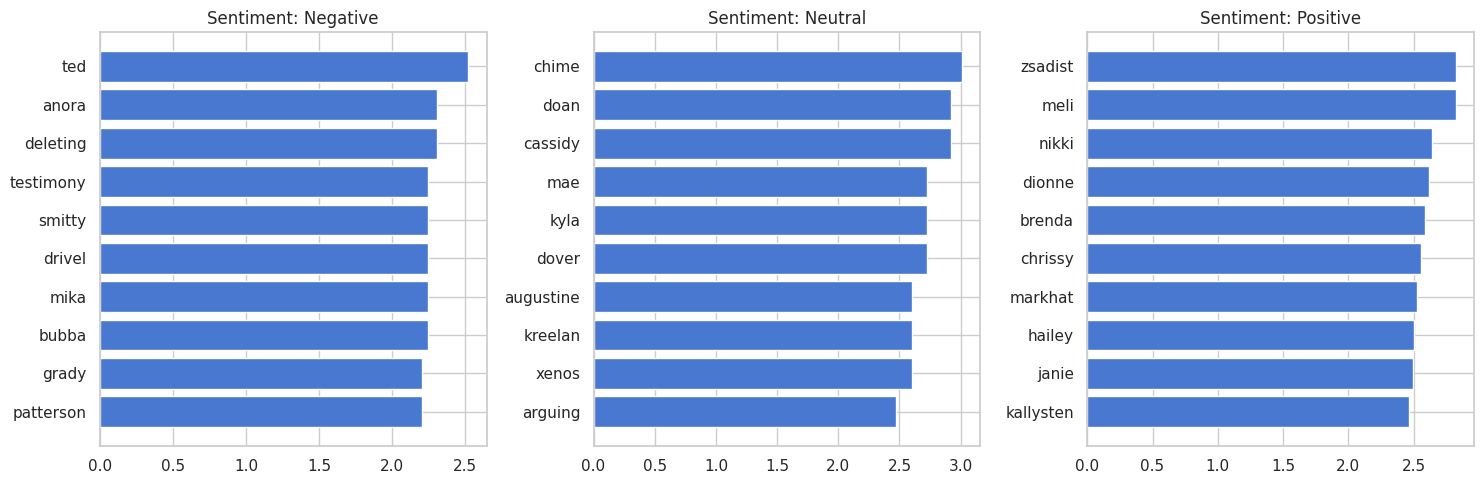

In [ ]:
# Load csv and sanity check
df = pd.read_csv("kindle_reviews.csv")
print(df.shape)
# The column is named 'rating', not 'overall'
df[["rating", "reviewText"]].head()

# Function to map star ratings to sentiment classes
def stars_to_sentiment(stars):
    if stars <= 2:
      return "negative"
    elif stars == 3:
      return "neutral"
    else:
      return "positive"

# Fixed typo 'overwall' to 'rating'
df["sentiment"] = df["rating"].apply(stars_to_sentiment)
df = df.dropna(subset=["reviewText"])
print(df["sentiment"].value_counts()) # to view class balance (theyre mostly positive)

# Preprocessing
def clean_text(text):
  text = text.lower()
  text = re.sub(r"<.*?>", " ", text)                                            #HTML leftover
  text = re.sub(r'[^a-z\s]', ' ', text)                                         #keep letters
  text = re.sub(r'\s+', ' ', text).strip()                                      #whitespace
  return text

df["texto_limpio"] = df["reviewText"].apply(clean_text)


#Train and test for both models
X_full = df['texto_limpio']
y_full = df['sentiment']

X_train_full, X_test_full, y_train_full, y_test_full = train_test_split(
    X_full,
    y_full,
    test_size=0.3,
    random_state=42,
    stratify=y_full
    )

# Baseline training subset: only positive/negative
train_bin_mask = y_train_full != "neutral"
X_train_bin, y_train_bin = X_train_full[train_bin_mask], y_train_full[train_bin_mask]

#Binary Classifier
pipeline_bin = Pipeline([
    ('vectorizer', CountVectorizer(stop_words='english', max_features=10000)),
    ('classifier', MultinomialNB(alpha=1.0))
])
pipeline_bin.fit(X_train_bin, y_train_bin)

y_pred_bin = pipeline_bin.predict(X_test_full)
print("Baseline (binary-only) — evaluated on full test set:")
print(classification_report(y_test_full, y_pred_bin))



#3 class classifier
pipeline_3class = Pipeline([
    ('vectorizer', CountVectorizer(stop_words='english', max_features=10000)),
    ('classifier', MultinomialNB(alpha=1.0))
])
pipeline_3class.fit(X_train_full, y_train_full)

y_pred_3c = pipeline_3class.predict(X_test_full)
print("Improved (3-class) — evaluated on same test set:")
print(classification_report(y_test_full, y_pred_3c))


#Validation: Robustness check
scores_3c = cross_val_score(pipeline_3class, X_full, y_full, cv=5, scoring='accuracy')
print(f"3-class model — 5-fold CV accuracy: {scores_3c.mean():.4f} (+/- {scores_3c.std()*2:.4f})")


# Get discriminative words per class
classifier = pipeline_3class.named_steps['classifier']
vectorizer = pipeline_3class.named_steps['vectorizer']
class_labels = classifier.classes_
feature_names = vectorizer.get_feature_names_out()
log_probs = classifier.feature_log_prob_

fig, axes = plt.subplots(1, 3, figsize=(15, 5))
for i, label in enumerate(class_labels):
    class_lp = log_probs[i]
    other_lp = np.delete(log_probs, i, axis=0)
    scores = class_lp - np.max(other_lp, axis=0)
    top_idx = np.argsort(scores)[-10:]
    axes[i].barh([feature_names[j] for j in top_idx], scores[top_idx])
    axes[i].set_title(f"Sentiment: {label.capitalize()}")
plt.tight_layout()
plt.show()